# Rain Tomorrow - XGBoost Hyperparameter Search with MLflow

Este notebook realiza la optimización de hiperparámetros para el modelo de predicción de lluvia
usando **XGBoost** con `GridSearchCV`, y loguea todos los experimentos en **MLflow**.

XGBoost fue seleccionado porque en nuestra experimentación previa (AMq_Trabajo_Final) fue el modelo
con mejor desempeño general (ROC-AUC: 0.878, F1: 0.617), superando a Random Forest y Logistic Regression.

**Autores:** Paola Blanco, Agustín Vazquez, Facundo Quiroga, Victor Peralta

## Prerequisitos
1. Ejecutar el DAG `process_etl_rain_data` en Airflow primero
2. Todos los servicios deben estar corriendo (`docker compose --profile all up`)
3. Configurar las variables de entorno para acceso a MinIO/S3

## Pasos
1. Cargar datos preprocesados desde S3
2. Definir el espacio de búsqueda de hiperparámetros de XGBoost
3. Ejecutar la optimización con tracking en MLflow
4. Registrar el mejor modelo en el MLflow Model Registry
5. Asignar el mejor modelo como 'champion'


In [21]:
import os

# Set environment variables for MinIO access
# Change localhost if running on a remote server
os.environ['AWS_ACCESS_KEY_ID'] = 'minio'
os.environ['AWS_SECRET_ACCESS_KEY'] = 'minio123'
os.environ['AWS_ENDPOINT_URL_S3'] = 'http://localhost:9000'
os.environ['MLFLOW_S3_ENDPOINT_URL'] = 'http://localhost:9000'

In [22]:
import mlflow
import awswrangler as wr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import (
    f1_score, accuracy_score, precision_score, recall_score,
    confusion_matrix, roc_curve, auc, RocCurveDisplay
)

# URI del servidor MLflow (cambiar 'localhost' si se ejecuta en un servidor remoto)
MLFLOW_TRACKING_URI = 'http://localhost:5001'
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)

print(f'MLflow tracking URI: {MLFLOW_TRACKING_URI}')
print(f'MLflow version: {mlflow.__version__}')


MLflow tracking URI: http://localhost:5001
MLflow version: 3.10.1


## 1. Load Data from S3

Load the preprocessed train and test datasets that were created by the ETL DAG.

In [23]:
# Load train and test data from S3
X_train = wr.s3.read_csv('s3://data/final/train/weather_X_train.csv')
y_train = wr.s3.read_csv('s3://data/final/train/weather_y_train.csv').values.ravel()
X_test = wr.s3.read_csv('s3://data/final/test/weather_X_test.csv')
y_test = wr.s3.read_csv('s3://data/final/test/weather_y_test.csv').values.ravel()

print(f'Training set: {X_train.shape[0]} samples, {X_train.shape[1]} features')
print(f'Test set: {X_test.shape[0]} samples, {X_test.shape[1]} features')
print(f'Target distribution (train): {np.bincount(y_train.astype(int))}')
print(f'Target distribution (test): {np.bincount(y_test.astype(int))}')

Training set: 87098 samples, 50 features
Test set: 37328 samples, 50 features
Target distribution (train): [67842 19256]
Target distribution (test): [29075  8253]


## 2. Búsqueda de Hiperparámetros con MLflow Tracking

Definimos el grilla de hiperparámetros de XGBoost y ejecutamos `GridSearchCV`.

**¿Por qué estos hiperparámetros?**
- `n_estimators`: número de árboles. Más árboles = más capacidad, pero más lento.
- `max_depth`: profundidad máxima de cada árbol. Controla la complejidad del modelo.
- `learning_rate`: tasa de aprendizaje (shrinkage). Valores bajos + muchos árboles suelen dar mejor resultado.
- `subsample`: fracción de muestras usadas por árbol. Ayuda a reducir overfitting.
- `scale_pos_weight`: ajuste para el desbalance de clases (hay ~4x más días sin lluvia que con lluvia).

Cada combinación es evaluada con 5-fold cross-validation optimizando F1-score (mejor métrica para datos desbalanceados).


In [24]:
# Crear o recuperar el experimento de MLflow
experiment = mlflow.set_experiment('Rain Prediction')

# Definir la grilla de hiperparámetros para XGBoost
# Basada en los mejores rangos conocidos para clasificación binaria con datos desbalanceados
param_grid = {
    'n_estimators': [100, 200, 300],       # número de árboles
    'max_depth': [3, 5, 7],                # profundidad máxima de cada árbol
    'learning_rate': [0.01, 0.1, 0.2],    # tasa de aprendizaje
    'subsample': [0.8, 1.0],              # fracción de datos por árbol
    'scale_pos_weight': [1, 4],           # 4 = aprox. ratio neg/pos en el dataset
}

print('Grilla de hiperparámetros:')
for key, values in param_grid.items():
    print(f'  {key}: {values}')

total_combinaciones = 1
for v in param_grid.values():
    total_combinaciones *= len(v)
print(f'\nTotal de combinaciones: {total_combinaciones}')
print(f'Total de fits (combinaciones × 5 folds): {total_combinaciones * 5}')


Grilla de hiperparámetros:
  n_estimators: [100, 200, 300]
  max_depth: [3, 5, 7]
  learning_rate: [0.01, 0.1, 0.2]
  subsample: [0.8, 1.0]
  scale_pos_weight: [1, 4]

Total de combinaciones: 108
Total de fits (combinaciones × 5 folds): 540


In [25]:
# Instanciar XGBoost
# use_label_encoder=False y eval_metric='logloss' evitan warnings de versiones recientes de XGBoost
xgb = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
)

# Ejecutar GridSearchCV
# n_jobs=-1 usa todos los CPUs disponibles para paralelizar la búsqueda
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=5,
    scoring='f1',        # optimizamos F1 por el desbalance de clases
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
)

grid_search.fit(X_train, y_train)

print(f'\nMejores parámetros: {grid_search.best_params_}')
print(f'Mejor F1 en CV (validación cruzada): {grid_search.best_score_:.4f}')


Fitting 5 folds for each of 108 candidates, totalling 540 fits


c:\Users\pandr\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:02:08] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Mejores parámetros: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300, 'scale_pos_weight': 4, 'subsample': 0.8}
Mejor F1 en CV (validación cruzada): 0.6309


## 3. Evaluate Best Model and Log to MLflow

In [26]:
# Get the best model
best_model = grid_search.best_estimator_

# Evaluate on test set
y_pred = best_model.predict(X_test)

test_f1 = f1_score(y_test, y_pred)
test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)

print(f'Test F1 Score:  {test_f1:.4f}')
print(f'Test Accuracy:  {test_accuracy:.4f}')
print(f'Test Precision: {test_precision:.4f}')
print(f'Test Recall:    {test_recall:.4f}')

Test F1 Score:  0.6290
Test Accuracy:  0.8008
Test Precision: 0.5347
Test Recall:    0.7637


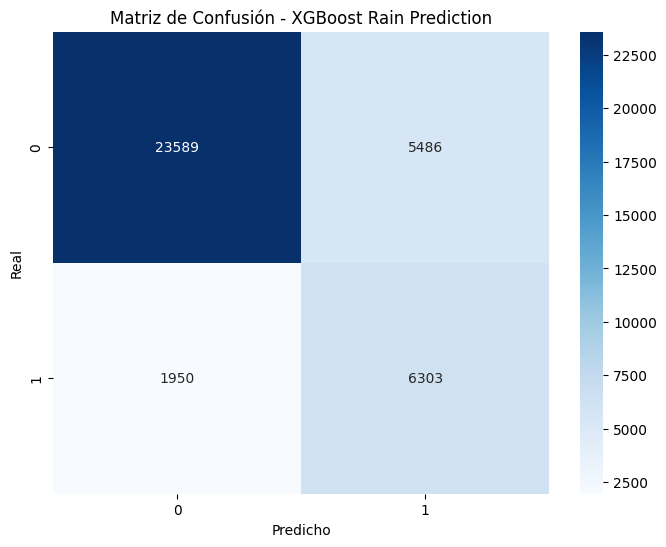

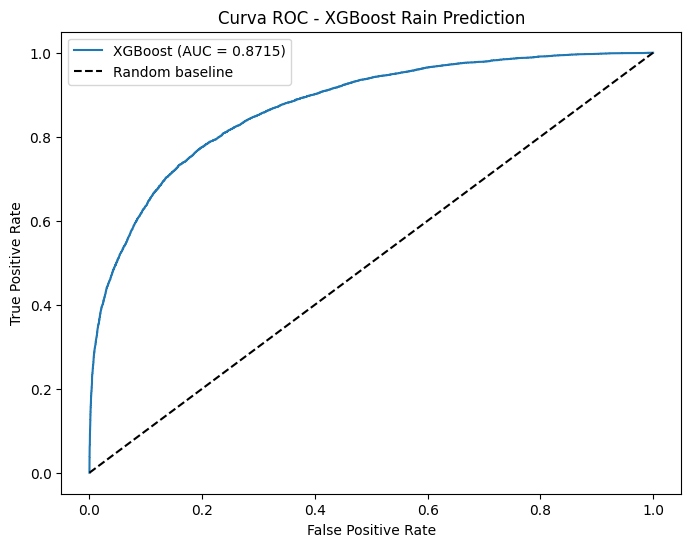

2026/04/04 13:02:37 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/04 13:02:38 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Run ID: f78d3a69e17342ae93de2b461a9ae291
Experiment ID: 1
🏃 View run best_xgboost_model at: http://localhost:5001/#/experiments/1/runs/f78d3a69e17342ae93de2b461a9ae291
🧪 View experiment at: http://localhost:5001/#/experiments/1


In [27]:
# Logguear el mejor modelo en MLflow
# mlflow.start_run() crea un "run" (experimento individual) que agrupa todos los logs
with mlflow.start_run(
    run_name='best_xgboost_model',
    experiment_id=experiment.experiment_id,
    tags={
        'experiment': 'hyperparameter_search',
        'model': 'XGBoost',
        'dataset': 'Rain in Australia',
        'search_method': 'GridSearchCV',
    },
) as run:
    # Loguear parámetros — quedan guardados en MLflow para reproducibilidad
    mlflow.log_params(grid_search.best_params_)
    mlflow.log_param('cv_folds', 5)

    # Loguear métricas — permiten comparar este run contra otros en la UI de MLflow
    mlflow.log_metric('f1_score', test_f1)
    mlflow.log_metric('accuracy', test_accuracy)
    mlflow.log_metric('precision', test_precision)
    mlflow.log_metric('recall', test_recall)
    mlflow.log_metric('cv_best_f1', grid_search.best_score_)

    # Generar y loguear la matriz de confusión como artefacto (imagen)
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')
    ax.set_title('Matriz de Confusión - XGBoost Rain Prediction')
    fig.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
    mlflow.log_artifact('confusion_matrix.png')
    plt.show()

    # Generar y loguear la curva ROC
    y_prob = best_model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(fpr, tpr, label=f'XGBoost (AUC = {roc_auc:.4f})')
    ax.plot([0, 1], [0, 1], 'k--', label='Random baseline')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('Curva ROC - XGBoost Rain Prediction')
    ax.legend()
    fig.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
    mlflow.log_artifact('roc_curve.png')
    mlflow.log_metric('roc_auc', roc_auc)
    plt.show()

    # Loguear el modelo — MLflow guarda el objeto sklearn completo en S3/MinIO
    # Esto permite cargarlo después con mlflow.sklearn.load_model()
    mlflow.sklearn.log_model(best_model, 'xgboost_rain_prediction')

    print(f'\nRun ID: {run.info.run_id}')
    print(f'Experiment ID: {experiment.experiment_id}')


## 4. Register Best Model as Champion

Register the best model in the MLflow model registry and set it as the 'champion'.

In [28]:
# Registrar el modelo en el MLflow Model Registry
# El registry centraliza las versiones del modelo de producción
model_name = 'rain_prediction_model_prod'
model_uri = f'runs:/{run.info.run_id}/xgboost_rain_prediction'

mv = mlflow.register_model(model_uri, model_name)
print(f'Modelo registrado: {model_name}, versión: {mv.version}')

# Asignar el alias 'champion' a esta versión
# El DAG de Airflow y la API de FastAPI usan este alias para saber cuál modelo servir.
# Si en el futuro se quiere cambiar el modelo, solo hay que mover el alias — sin tocar el código.
client = mlflow.MlflowClient()
client.set_registered_model_alias(model_name, 'champion', mv.version)
print(f'Versión {mv.version} asignada como champion!')


Registered model 'rain_prediction_model_prod' already exists. Creating a new version of this model...
2026/04/04 13:03:36 WARNING mlflow.tracking._model_registry.fluent: Run with id f78d3a69e17342ae93de2b461a9ae291 has no artifacts at artifact path 'xgboost_rain_prediction', registering model based on models:/m-a408a640de6c43669d274ea4fb4baa22 instead
2026/04/04 13:03:36 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: rain_prediction_model_prod, version 2
Created version '2' of model 'rain_prediction_model_prod'.


Modelo registrado: rain_prediction_model_prod, versión: 2
Versión 2 asignada como champion!


## 5. Verify: Load and Test the Champion Model

In [29]:
# Verificar cargando el modelo champion desde el registry
# Esto simula lo que hace la API de FastAPI en producción para hacer predicciones
champion_data = client.get_model_version_by_alias(model_name, 'champion')
champion_model = mlflow.sklearn.load_model(champion_data.source)

# Prueba rápida de predicción
test_pred = champion_model.predict(X_test[:5])
print(f'Versión del modelo champion: {champion_data.version}')
print(f'Predicciones (primeras 5): {test_pred}')
print(f'Valores reales (primeras 5): {y_test[:5]}')
print('\nEl modelo está listo para ser servido por el endpoint de FastAPI!')


Versión del modelo champion: 2
Predicciones (primeras 5): [1 1 0 0 0]
Valores reales (primeras 5): [0. 1. 0. 0. 0.]

El modelo está listo para ser servido por el endpoint de FastAPI!
